In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"pulsar_star.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
...,...,...,...,...,...,...,...,...,...
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


# 펄서와 우주잡음의 분류(classification) 문제 - KNN이 필요한 모델
- 펄서 별(Pulsar Star) 데이터셋은 지구에 도착한 전파 관측 신호를 바탕으로 치이익- 하는 배경 우주 잡음과 진짜 펄서 별이 보내는 맥박 형태의 전파 신호를 구별하는 이진 분류(Binary Classification) 데이터셋입니다. 자전하며 주기적인 빔을 쏘는 펄서 특유의 물리적 성질 때문에, 일반 잡음과 달리 평균 신호 세기(signal_power)는 낮고 신호의 변동 폭(signal_spread)은 크게 튀는 독특한 데이터 분포를 가집니다.

### 펄서 별(Pulsar Star) 데이터셋 컬럼 명세

| 컬럼명 | 데이터 타입 | 설명 |
| :--- | :--- | :--- |
| **Mean of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **평균값** (신호의 전체적인 세기) |
| **Standard deviation of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **표준편차** (신호 세기의 변동폭) |
| **Excess kurtosis of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **첨도** (신호 분포의 뾰족함 정도) |
| **Skewness of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **왜도** (신호 분포의 치우침 정도) |
| **Mean of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **평균값** |
| **Standard deviation of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **표준편차** |
| **Excess kurtosis of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **첨도** |
| **Skewness of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **왜도** |
| **target_class** | Integer | **클래스 라벨 (0: 우주 잡음 / 1: 진짜 펄서 별)** |

In [10]:
star_df = df[[" Mean of the integrated profile", " Standard deviation of the integrated profile", "target_class"]]

star_df.columns = ["signal_mean_power", "signal_spread", "target"]
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [11]:
star_df["target"].value_counts()

target
0.0    11375
1.0     1153
Name: count, dtype: int64

## 언더 샘플링(데이터 불균형 해결)

In [14]:
df_0 = star_df[star_df["target"] == 0]
df_1 = star_df[star_df["target"] == 1]

print(len(df_0), len(df_1))

df_sampled = df_0.sample(n=len(df_1), random_state=2026)
print(len(df_sampled))

11375 1153
1153


In [15]:
star_df = pd.concat([df_1, df_sampled]).sample(frac=1, random_state=2026).reset_index(drop=True)

In [17]:
star_df

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0.0
1,25.437500,38.225636,1.0
2,34.023438,32.876299,1.0
3,101.093750,47.496289,0.0
4,101.945312,39.955309,0.0
...,...,...,...
2301,155.460938,39.429506,0.0
2302,126.000000,45.366046,0.0
2303,40.062500,30.721722,1.0
2304,40.929688,30.200937,1.0


# 사이킬런 KNN 분류 사이클 실습

## 데이터 탐색

In [22]:
star_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  2306 non-null   float64
 1   signal_spread      2306 non-null   float64
 2   target             2306 non-null   float64
dtypes: float64(3)
memory usage: 54.2 KB


In [20]:
star_df.describe()

,signal_mean_power,signal_spread,target
count,2306.000000,2306.000000,2306.000000
mean,87.201340,42.994349,0.500000
std,39.140325,8.200844,0.500108
min,5.812500,24.772042,0.000000
25%,54.300781,36.709625,0.000000
50%,96.570312,43.612955,0.500000
75%,118.986328,49.000045,1.000000
max,189.734375,90.250557,1.000000


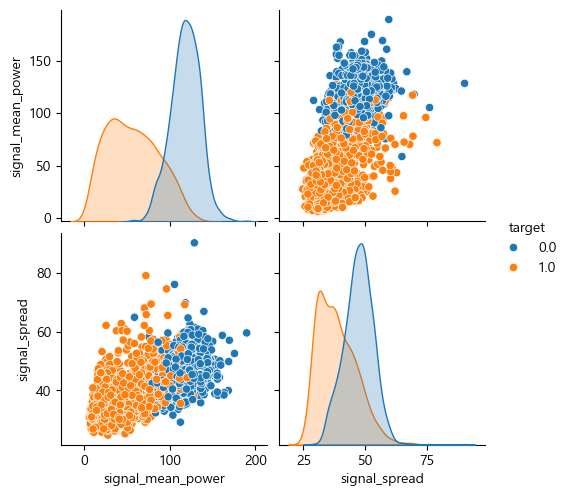

In [21]:
sns.pairplot(star_df, hue="target")
plt.show()

## 데이터 분할

In [121]:
X = star_df.drop("target", axis=1)

In [122]:
y = star_df["target"].astype(int)

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(1844, 2) (462, 2) (1844,) (462,)


In [126]:
# 정규화
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 모델 준비

In [127]:
svc = SVC()

## 모델 학습

In [128]:
svc.fit(X_train_scaled, y_train)

SVC()

## 모델 예측

In [129]:
y_pred = svc.predict(X_test_scaled)
print(y_pred)
print(list(y_test))

[1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 1 0 0
 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0
 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 1
 0 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 0 1 1
 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1 1
 0 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1
 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1
 0 1 1 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0
 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0
 1 0 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 0 0 1
 1 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 0 0
 0 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0
 0 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1]
[1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1

## 모델 평가

In [130]:
svc.score(X_train_scaled, y_train)

0.8969631236442517

In [131]:
svc.score(X_test_scaled, y_test)

0.8939393939393939

In [132]:
columns = X_train.columns

star_scaled_df = pd.DataFrame(X_train_scaled, columns=columns)
star_scaled_df["target"] = y_train
star_scaled_df

,signal_mean_power,signal_spread,target
0,0.626795,0.363997,0.0
1,0.434458,0.287278,NaN
2,0.620678,0.240134,1.0
3,0.596338,0.536454,0.0
4,0.408589,0.202696,0.0
...,...,...,...
1839,0.225045,0.706155,NaN
1840,0.628579,0.445590,1.0
1841,0.513465,0.488065,0.0
1842,0.259451,0.160361,1.0


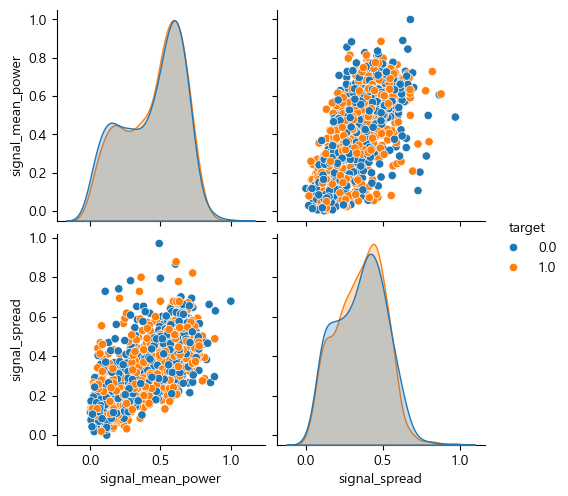

In [133]:
sns.pairplot(star_scaled_df, hue="target")
plt.show()

In [134]:
cm = confusion_matrix(y_test, y_pred)

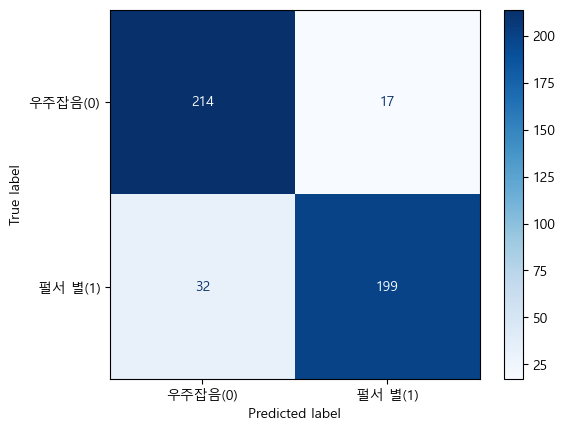

In [135]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["우주잡음(0)", "펄서 별(1)"])
cm_display.plot(cmap="Blues")
plt.show()